In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('acq.csv')

In [3]:
data.head()

,company_permalink,company_name,company_category_list,company_country_code,company_state_code,company_region,company_city,acquirer_permalink,acquirer_name,acquirer_category_list,acquirer_country_code,acquirer_state_code,acquirer_region,acquirer_city,acquired_at,acquired_month,price_amount,price_currency_code
0,/organization/003-ru,003.RU,Consumer Electronics|Electronics|Internet,RUS,48,Moscow,Moscow,/organization/media-saturn,Media Saturn,Enterprise Software|Media|Sales and Marketing,ESP,56,Barcelona,Barcelona,2012-07-23,2012-07,NaN,USD
1,/organization/0958572-b-c-ltd,0958572 B.C. Ltd.,NaN,NaN,NaN,NaN,NaN,/organization/atlas-intellectual-property-mana...,ATLAS Intellectual Property Management Co.,Finance|FinTech|Mobile|Telecommunications,USA,WA,Seattle,Seattle,2012-02-02,2012-02,9000000.0,USD
2,/organization/1-800-communications,1-800 Communications,NaN,USA,NY,Long Island,Hicksville,/organization/carsdirect-com,CarsDirect.com,E-Commerce,USA,CA,Los Angeles,El Segundo,2005-06-12,2005-06,NaN,USD
3,/organization/1-800-contacts,1-800 Contacts,Consumer Goods|Retail,USA,UT,Salt Lake City,Draper,/organization/thomas-h-lee-partners,Thomas H. Lee Partners,Business Development|Impact Investing|Investme...,USA,MA,Boston,Boston,2014-01-07,2014-01,NaN,USD
4,/organization/1-844-446-4460-pogo-customer-ser...,Games Support +1-800-311-5934 Pogo Games techn...,NaN,NaN,NaN,NaN,NaN,/organization/pogo-customer-service-number-1-8...,Games Support +1-800-311-5934 Pogo Games techn...,NaN,USA,NY,New York City,Mamaroneck,2001-02-02,2001-02,NaN,USD


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18968 entries, 0 to 18967
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_permalink       18968 non-null  object 
 1   company_name            18968 non-null  object 
 2   company_category_list   13985 non-null  object 
 3   company_country_code    14300 non-null  object 
 4   company_state_code      14020 non-null  object 
 5   company_region          14058 non-null  object 
 6   company_city            14058 non-null  object 
 7   acquirer_permalink      18968 non-null  object 
 8   acquirer_name           18968 non-null  object 
 9   acquirer_category_list  16580 non-null  object 
 10  acquirer_country_code   17798 non-null  object 
 11  acquirer_state_code     17533 non-null  object 
 12  acquirer_region         17609 non-null  object 
 13  acquirer_city           17609 non-null  object 
 14  acquired_at             18956 non-null

In [5]:
data.size

341424

In [6]:
data.shape

(18968, 18)

In [7]:
data.describe()

,price_amount
count,5.012000e+03
mean,8.765321e+08
std,4.285793e+09
min,0.000000e+00
25%,2.067500e+07
50%,9.990000e+07
75%,3.900000e+08
max,1.600000e+11


In [8]:
data.columns


Index(['company_permalink', 'company_name', 'company_category_list',
       'company_country_code', 'company_state_code', 'company_region',
       'company_city', 'acquirer_permalink', 'acquirer_name',
       'acquirer_category_list', 'acquirer_country_code',
       'acquirer_state_code', 'acquirer_region', 'acquirer_city',
       'acquired_at', 'acquired_month', 'price_amount', 'price_currency_code'],
      dtype='object')

In [9]:
data.isnull().sum()

company_permalink             0
company_name                  0
company_category_list      4983
company_country_code       4668
company_state_code         4948
company_region             4910
company_city               4910
acquirer_permalink            0
acquirer_name                 0
acquirer_category_list     2388
acquirer_country_code      1170
acquirer_state_code        1435
acquirer_region            1359
acquirer_city              1359
acquired_at                  12
acquired_month               14
price_amount              13956
price_currency_code           6
dtype: int64

<Axes: >

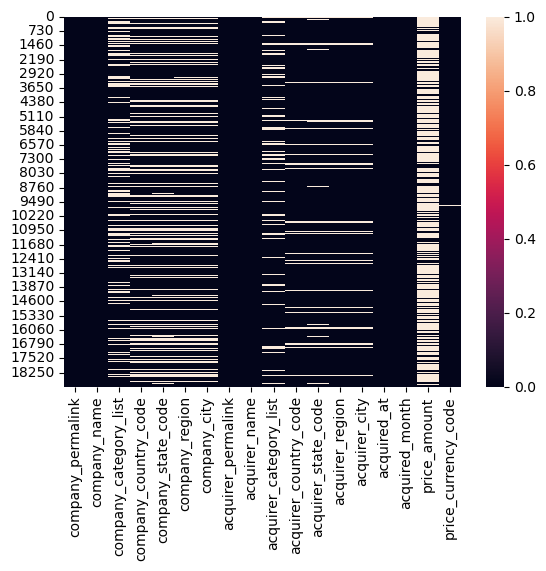

In [10]:
sns.heatmap(data.isnull(),cbar=True)

In [11]:
location = [
'company_category_list',
'company_country_code',
'company_state_code',
'company_region',
'company_city',
'acquirer_category_list',
'acquirer_country_code',
'acquirer_state_code',
'acquirer_region',
'acquirer_city'
]

for i in location:
    data[i] = data[i].fillna('Unknown')

In [12]:
data.drop('acquired_month', axis=1, inplace=True)

In [13]:
data['price_currency_code'].value_counts()

price_currency_code
USD    18525
EUR      201
GBP      160
CAD       25
AUD       18
JPY        9
SEK        6
NZD        5
NOK        3
CHF        2
KRW        1
RON        1
INR        1
MAD        1
SDG        1
DKK        1
AZN        1
SAR        1
Name: count, dtype: int64

In [14]:
# Create exchange rates
exchange_rates = {
    'USD': 1,
    'EUR': 1.09,
    'GBP': 1.27,
    'CAD': 0.74,
    'AUD': 0.66,
    'JPY': 0.0067,
    'SEK': 0.095,
    'NZD': 0.62,
    'NOK': 0.094,
    'CHF': 1.10,
    'KRW': 0.00075,
    'RON': 0.22,
    'INR': 0.012,
    'MAD': 0.10,
    'SDG': 0.002,
    'DKK': 0.15,
    'AZN': 0.59,
    'SAR': 0.27
}

# Map rate
data['rate'] = data['price_currency_code'].map(exchange_rates)

# Convert
data['price_amount_usd'] = data['price_amount'] * data['rate']

In [15]:
data['price_amount_usd'].isnull().sum()

np.int64(13956)

In [16]:
data['price_amount_usd']=data['price_amount_usd'].fillna(data['price_amount_usd'].median())

In [17]:
data['price_currency_code'] = data['price_currency_code'].fillna('Unknown')
data['rate'] = data['rate'].fillna('Unknown')


In [18]:
data.isnull().sum()

company_permalink             0
company_name                  0
company_category_list         0
company_country_code          0
company_state_code            0
company_region                0
company_city                  0
acquirer_permalink            0
acquirer_name                 0
acquirer_category_list        0
acquirer_country_code         0
acquirer_state_code           0
acquirer_region               0
acquirer_city                 0
acquired_at                  12
price_amount              13956
price_currency_code           0
rate                          0
price_amount_usd              0
dtype: int64

In [19]:
data['company_category_list'].value_counts()

company_category_list
Unknown                                             4983
Software                                            1459
Curated Web                                          580
Biotechnology                                        546
Enterprise Software                                  398
                                                    ... 
SaaS|Sales and Marketing|Software                      1
Application Platforms|Service Providers|Services       1
Consulting|Design|User Experience Design               1
FreetoPlay Gaming|Games|MMO Games                      1
CA                                                     1
Name: count, Length: 5931, dtype: int64

In [20]:
top_categories = data['company_category_list'].value_counts().head(10)

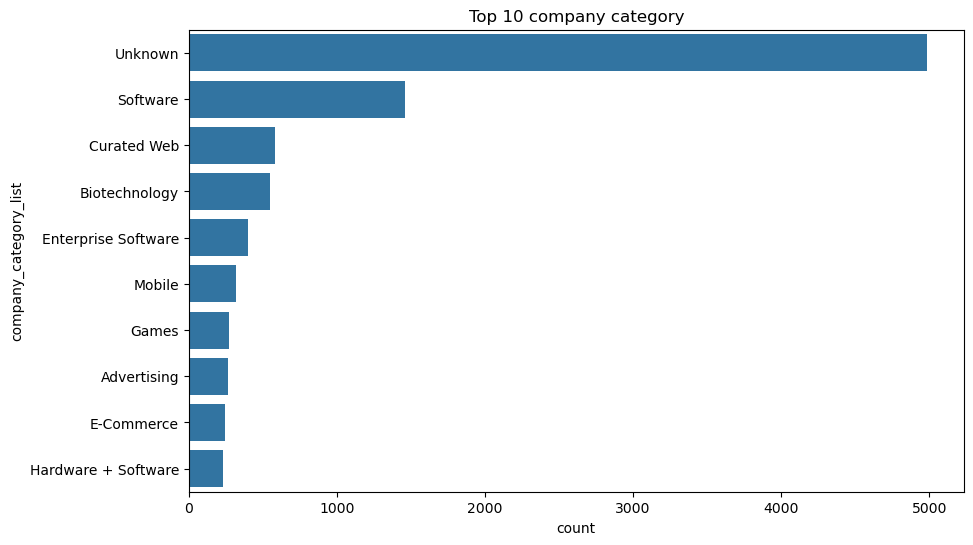

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(y='company_category_list',data=data,order=top_categories.index)
plt.title('Top 10 company category')
plt.show()

In [22]:
data['company_country_code'].value_counts()

company_country_code
USA            10468
Unknown         4668
GBR              934
CAN              503
DEU              289
               ...  
BLR                1
MLT                1
MDA                1
IRN                1
SF Bay Area        1
Name: count, Length: 87, dtype: int64

In [23]:
top_countries_with_statups=data['company_country_code'].value_counts().head(10)

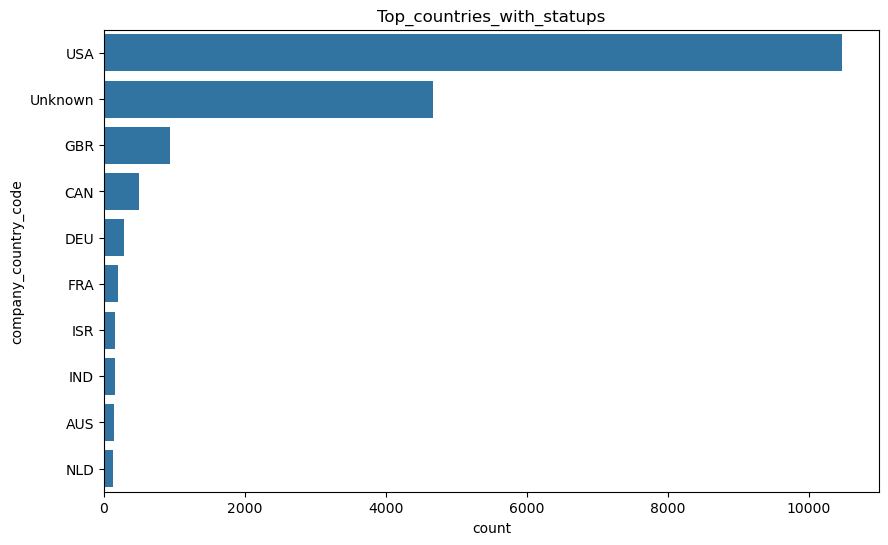

In [24]:
plt.figure(figsize=(10,6))

sns.countplot(y='company_country_code',data=data,order=top_countries_with_statups.index)
plt.title('Top_countries_with_statups')
plt.show()

In [25]:
data['acquirer_category_list'].value_counts()

acquirer_category_list
Unknown                                                                                                       2388
Software                                                                                                      1233
Biotechnology                                                                                                  526
Hardware + Software                                                                                            308
Enterprise Software                                                                                            307
                                                                                                              ... 
Application Performance Monitoring|Cloud Infrastructure|Developer APIs|Developer Tools|Enterprise Software       1
Banking|Financial Services|Technology                                                                            1
Gift Exchange|Online Shopping|Shopping                   

In [26]:
top_acquired = data['acquirer_category_list'].value_counts().head(10)

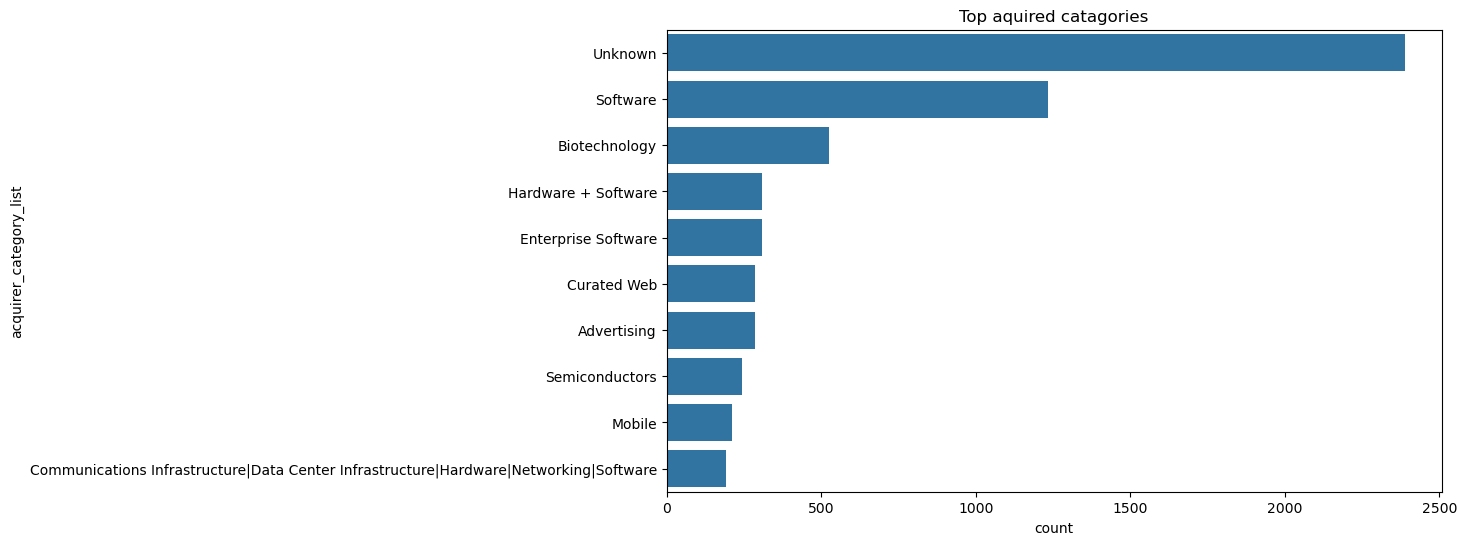

In [27]:
plt.figure(figsize=(10,6))

sns.countplot(y='acquirer_category_list',data=data,order=top_acquired.index)
plt.title('Top aquired catagories')
plt.show()

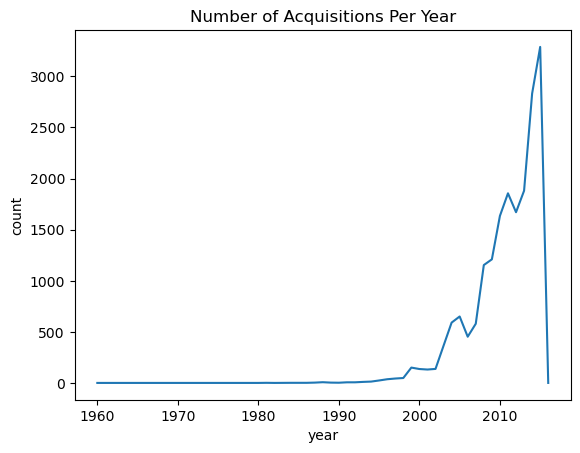

In [34]:
# Convert to datetime safely
data['acquired_at'] = pd.to_datetime(data['acquired_at'], errors='coerce')

# Extract year
data['year'] = data['acquired_at'].dt.year

# Remove rows where year or price is missing
clean_data = data.dropna(subset=['year'])

yearly_count = clean_data.groupby('year').size().reset_index(name='count')

sns.lineplot(x='year', y='count', data=yearly_count)
plt.title("Number of Acquisitions Per Year")
plt.show()

<Axes: xlabel='acquirer_name'>

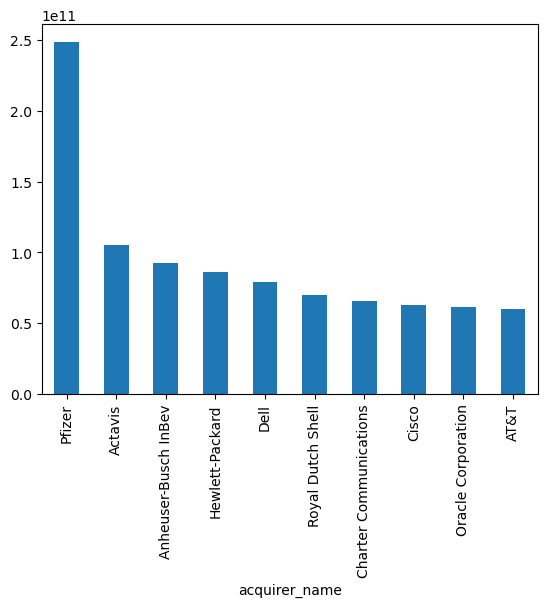

In [40]:
top_acquirers = data.groupby('acquirer_name')['price_amount_usd'].sum().sort_values(ascending=False).head(10)

top_acquirers.plot(kind='bar')

<Axes: xlabel='cross_border', ylabel='count'>

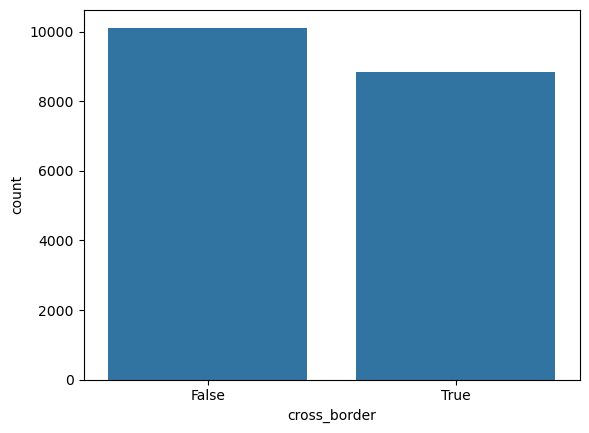

In [41]:
data['cross_border'] = data['company_country_code'] != data['acquirer_country_code']

data['cross_border'].value_counts()
sns.countplot(x='cross_border', data=data)

<Axes: xlabel='company_region', ylabel='price_amount_usd'>

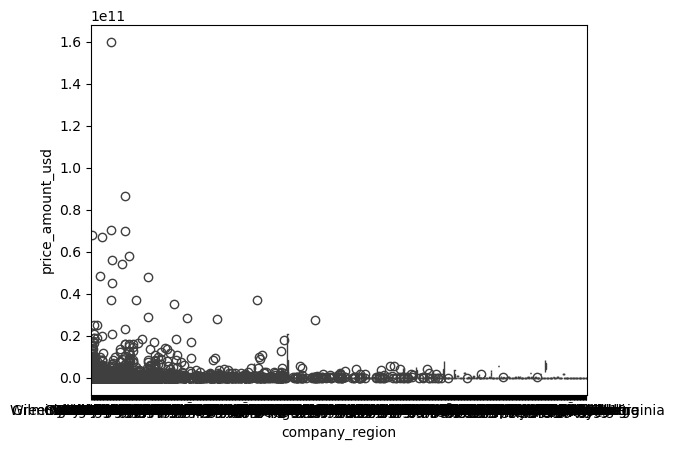

In [43]:
sns.boxplot(
    x='company_region',
    y='price_amount_usd',
    data=data
)

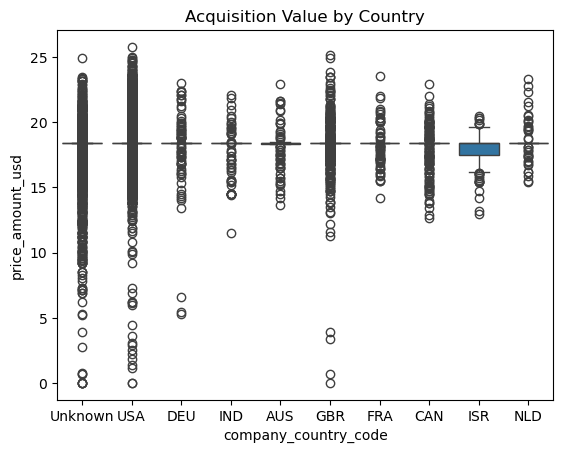

In [44]:
top_countries = data['company_country_code'].value_counts().head(10).index

filtered = data[data['company_country_code'].isin(top_countries)]

sns.boxplot(
    x='company_country_code',
    y=np.log1p(filtered['price_amount_usd']),
    data=filtered
)
plt.title("Acquisition Value by Country")
plt.show()

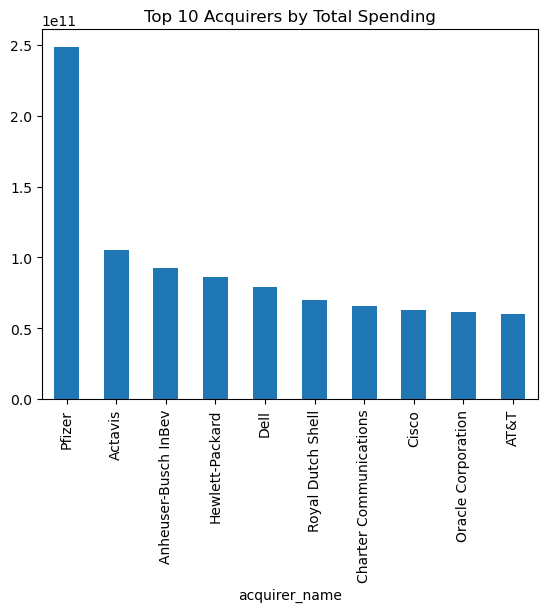

In [45]:
top_spenders = (
    data.groupby('acquirer_name')['price_amount_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_spenders.plot(kind='bar')
plt.title("Top 10 Acquirers by Total Spending")
plt.show()